<a href="https://colab.research.google.com/github/AllaYermilko/DTA-2026/blob/main/project_store_sales_analysis/store_sales_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Аналаіз продажів магазину

Вхідний датасет

In [1]:
# Запусти цей блок, щоб отримати датасет
import pandas as pd
import numpy as np

np.random.seed(42)
n = 300

categories = ['Молочне', 'Хліб та випічка', 'М\'ясо та риба', 'Овочі та фрукти', 'Напої']
products = {
    'Молочне':          ['Молоко 1л', 'Кефір 0.5л', 'Сир кисломолочний', 'Масло вершкове', 'Йогурт'],
    'Хліб та випічка':  ['Хліб білий', 'Батон', 'Булочка', 'Хліб житній', 'Круасан'],
    'М\'ясо та риба':   ['Куряче філе', 'Свинина', 'Ковбаса', 'Риба хек', 'Сосиски'],
    'Овочі та фрукти':  ['Картопля', 'Морква', 'Яблука', 'Банани', 'Помідори'],
    'Напої':            ['Вода 1.5л', 'Сік апельсиновий', 'Чай', 'Кава мелена', 'Лимонад'],
}
prices = {
    'Молоко 1л': 38, 'Кефір 0.5л': 22, 'Сир кисломолочний': 55, 'Масло вершкове': 95, 'Йогурт': 30,
    'Хліб білий': 28, 'Батон': 25, 'Булочка': 12, 'Хліб житній': 32, 'Круасан': 18,
    'Куряче філе': 165, 'Свинина': 210, 'Ковбаса': 145, 'Риба хек': 120, 'Сосиски': 98,
    'Картопля': 20, 'Морква': 15, 'Яблука': 45, 'Банани': 52, 'Помідори': 60,
    'Вода 1.5л': 18, 'Сік апельсиновий': 68, 'Чай': 85, 'Кава мелена': 155, 'Лимонад': 35,
}

chosen_cats = np.random.choice(categories, n, p=[0.25, 0.20, 0.20, 0.20, 0.15])
chosen_products = [np.random.choice(products[c]) for c in chosen_cats]

df_origin = pd.DataFrame({
    'transaction_id': range(1001, 1001 + n),
    'date':           pd.to_datetime(
                          np.random.choice(pd.date_range('2024-03-01', '2024-03-31'), n)
                      ),
    'hour':           np.random.choice(range(8, 21), n, p=[0.04,0.06,0.08,0.10,0.12,0.12,0.11,0.10,0.09,0.08,0.06,0.04,0.00]),
    'category':       chosen_cats,
    'product':        chosen_products,
    'quantity':       np.random.randint(1, 6, n),
    'price_uah':      [prices[p] for p in chosen_products],
    'customer_age':   np.random.randint(18, 70, n),
    'payment':        np.random.choice(['Готівка', 'Картка', 'Телефон'], n, p=[0.35, 0.50, 0.15]),
})


In [2]:
df = df_origin.copy()

In [3]:
df

,transaction_id,date,hour,category,product,quantity,price_uah,customer_age,payment
0,1001,2024-03-17,17,Хліб та випічка,Круасан,4,18,28,Готівка
1,1002,2024-03-13,14,Напої,Кава мелена,3,155,40,Картка
2,1003,2024-03-01,18,Овочі та фрукти,Яблука,1,45,43,Картка
3,1004,2024-03-02,8,М'ясо та риба,Риба хек,3,120,51,Готівка
4,1005,2024-03-09,19,Молочне,Йогурт,5,30,63,Картка
...,...,...,...,...,...,...,...,...,...
295,1296,2024-03-08,10,М'ясо та риба,Сосиски,4,98,48,Готівка
296,1297,2024-03-05,13,Овочі та фрукти,Морква,5,15,28,Телефон
297,1298,2024-03-04,11,Молочне,Молоко 1л,3,38,27,Картка
298,1299,2024-03-24,14,М'ясо та риба,Ковбаса,1,145,20,Готівка


1. Виведи перші 7 рядків датафрейму.

In [4]:
df.head(7)

,transaction_id,date,hour,category,product,quantity,price_uah,customer_age,payment
0,1001,2024-03-17,17,Хліб та випічка,Круасан,4,18,28,Готівка
1,1002,2024-03-13,14,Напої,Кава мелена,3,155,40,Картка
2,1003,2024-03-01,18,Овочі та фрукти,Яблука,1,45,43,Картка
3,1004,2024-03-02,8,М'ясо та риба,Риба хек,3,120,51,Готівка
4,1005,2024-03-09,19,Молочне,Йогурт,5,30,63,Картка
5,1006,2024-03-03,13,Молочне,Кефір 0.5л,3,22,51,Картка
6,1007,2024-03-31,15,Молочне,Масло вершкове,2,95,46,Телефон


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   transaction_id  300 non-null    int64         
 1   date            300 non-null    datetime64[ns]
 2   hour            300 non-null    int64         
 3   category        300 non-null    object        
 4   product         300 non-null    object        
 5   quantity        300 non-null    int64         
 6   price_uah       300 non-null    int64         
 7   customer_age    300 non-null    int64         
 8   payment         300 non-null    object        
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 21.2+ KB


In [6]:
df["total_uah"] = df.quantity * df.price_uah

In [7]:
df.dtypes

,0
transaction_id,int64
date,datetime64[ns]
hour,int64
category,object
product,object
quantity,int64
price_uah,int64
customer_age,int64
payment,object
total_uah,int64


In [8]:
print(f"Розмір: {df.shape[0]} рядків x {df.shape[1]} стовпців")

Розмір: 300 рядків x 10 стовпців


In [9]:
print("Типи даних:")
display(df.dtypes)

Типи даних:


,0
transaction_id,int64
date,datetime64[ns]
hour,int64
category,object
product,object
quantity,int64
price_uah,int64
customer_age,int64
payment,object
total_uah,int64


4. Перевір, чи є пропущені значення.

In [10]:
print(f"Пропущені значення (по стовпцях): \n\n{df.isnull().sum()}")

Пропущені значення (по стовпцях): 

transaction_id    0
date              0
hour              0
category          0
product           0
quantity          0
price_uah         0
customer_age      0
payment           0
total_uah         0
dtype: int64


5. Виведи основну статистику (describe) для числових стовпців.

In [11]:
print("Статистика:\n")
df.describe().round(2)

Статистика:



,transaction_id,date,hour,quantity,price_uah,customer_age,total_uah
count,300.00,300,300.00,300.00,300.00,300.0,300.00
mean,1150.50,2024-03-16 02:14:24,13.72,2.97,63.45,43.0,186.97
min,1001.00,2024-03-01 00:00:00,8.00,1.00,12.00,18.0,12.00
25%,1075.75,2024-03-08 00:00:00,12.00,2.00,22.00,31.0,60.00
50%,1150.50,2024-03-16 12:00:00,14.00,3.00,38.00,42.5,120.00
75%,1225.25,2024-03-24 00:00:00,16.00,4.00,95.75,55.0,256.25
max,1300.00,2024-03-31 00:00:00,19.00,5.00,210.00,69.0,840.00
std,86.75,NaN,2.74,1.44,51.68,14.6,180.27


**ВИСНОВОК**:
Датасет містить інформацію про 300 транзакцій, має 10 стовпців, пропущених значень немає.
Середня сума чеку 186,97 грн.
Мінімальний чек - 12,00 грн. ()
Максимальний чек - 840,00 грн. ()
Підозрілих даних не виявлено.

# **Блок 2 - Фільтрація та відбір**

**1. Відбери всі покупки категорії «М'ясо та риба»**

In [12]:
df[df["category"] == "М'ясо та риба"].head()

,transaction_id,date,hour,category,product,quantity,price_uah,customer_age,payment,total_uah
3,1004,2024-03-02,8,М'ясо та риба,Риба хек,3,120,51,Готівка,360
8,1009,2024-03-21,15,М'ясо та риба,Ковбаса,2,145,34,Картка,290
17,1018,2024-03-06,14,М'ясо та риба,Куряче філе,3,165,69,Картка,495
20,1021,2024-03-23,9,М'ясо та риба,Куряче філе,3,165,64,Телефон,495
24,1025,2024-03-10,14,М'ясо та риба,Свинина,4,210,28,Картка,840


In [13]:
meat_fish = df[df["category"] == "М'ясо та риба"]
print(f'У категорії "M\'ясо та риба": {len(meat_fish)} транзакцій')

У категорії "M'ясо та риба": 61 транзакцій


**2. Знайди транзакції, де сума (total_uah) перевищує 500 грн.**

In [14]:
big = df[df["total_uah"] > 500]
print(f"Покупки > 500 грн: {len(big)}\n")
print(big[['product', 'quantity', 'total_uah']].head())
# display(big[['product', 'quantity', 'total_uah']].head())

Покупки > 500 грн: 17

        product  quantity  total_uah
24      Свинина         4        840
28  Куряче філе         4        660
81      Ковбаса         4        580
89     Риба хек         5        600
93      Свинина         3        630


Відсоток веиких покупок

In [15]:
pct_big = len(big) / len(df) * 100
#  round(pct_big, 1)
print(f"Частка покупок > 500: {pct_big:.1f} %")

Частка покупок > 500: 5.7 %


In [16]:
for cat in big.category.unique():
  print(f"{cat} - {big['category'].count()}")

М'ясо та риба - 17
Напої - 17


**3.Відбери покупки, зроблені карткою (payment == 'Картка'), кількістю більше 2 одиниць.**

In [17]:
card_mult = df[(df['payment'] == 'Картка') & (df['quantity'] > 2)]
print("Картка + кількість > 2:", len(card_mult), "\n")
card_mult.head()

Картка + кількість > 2: 92 



,transaction_id,date,hour,category,product,quantity,price_uah,customer_age,payment,total_uah
1,1002,2024-03-13,14,Напої,Кава мелена,3,155,40,Картка,465
4,1005,2024-03-09,19,Молочне,Йогурт,5,30,63,Картка,150
5,1006,2024-03-03,13,Молочне,Кефір 0.5л,3,22,51,Картка,66
10,1011,2024-03-23,13,Молочне,Сир кисломолочний,5,55,30,Картка,275
17,1018,2024-03-06,14,М'ясо та риба,Куряче філе,3,165,69,Картка,495


**4. Знайди всі покупки покупців молодше 25 років.**

In [18]:
young = df[df["customer_age"] < 25]
print("Покупців до 25 років: ", len(young), "\n")
young.head()

Покупців до 25 років:  36 



,transaction_id,date,hour,category,product,quantity,price_uah,customer_age,payment,total_uah
7,1008,2024-03-01,17,Напої,Сік апельсиновий,1,68,21,Готівка,68
19,1020,2024-03-21,16,Хліб та випічка,Круасан,1,18,19,Готівка,18
26,1027,2024-03-19,13,Молочне,Йогурт,3,30,20,Готівка,90
36,1037,2024-03-04,14,Хліб та випічка,Круасан,1,18,23,Телефон,18
38,1039,2024-03-01,10,Овочі та фрукти,Помідори,1,60,22,Готівка,60


**5. Скільки унікальних товарів є в датасеті?**

In [19]:
n_unique = df["product"].nunique()
n_unique

pr_unique = df["product"].unique()
pr_unique

print("Кількість унікальних товарів:", n_unique, "\n")
print("Перелік унікальних товарів:", pr_unique, "\n")

Кількість унікальних товарів: 25 

Перелік унікальних товарів: [np.str_('Круасан') np.str_('Кава мелена') np.str_('Яблука')
 np.str_('Риба хек') np.str_('Йогурт') np.str_('Кефір 0.5л')
 np.str_('Масло вершкове') np.str_('Сік апельсиновий') np.str_('Ковбаса')
 np.str_('Картопля') np.str_('Сир кисломолочний') np.str_('Морква')
 np.str_('Куряче філе') np.str_('Хліб житній') np.str_('Батон')
 np.str_('Хліб білий') np.str_('Свинина') np.str_('Сосиски')
 np.str_('Молоко 1л') np.str_('Помідори') np.str_('Лимонад')
 np.str_('Булочка') np.str_('Банани') np.str_('Вода 1.5л') np.str_('Чай')] 



**ВИСНОВОК:**  

Близько половини покупок було сплачено карткою, з яких третина - більше 2х товарів у чеку.
5,7% транзакцій перевищують чек у розмірі 500 грн, здебільшого в категорії "м'ясо та риба".  
12% покупців молодшого віку (до 25 років)

# **Блок 3 - Групування та агрегація**

**1. Підрахуй загальний виторг по кожній категорії. Відсортуй за спаданням.**

In [20]:
# revenue_by_cat =
df.groupby('category')["total_uah"].sum().sort_values(ascending=False)

,total_uah
category,
М'ясо та риба,25223
Напої,10389
Молочне,10075
Овочі та фрукти,6270
Хліб та випічка,4134


**2. Знайди топ-5 товарів за кількістю проданих одиниць (сума quantity).**

In [21]:
df.groupby('category').agg({"total_uah": "sum", "quantity": "sum", "transaction_id": "count"}).sort_values(by=["total_uah", "transaction_id"], ascending=False)

,total_uah,quantity,transaction_id
category,,,
М'ясо та риба,25223,186,61
Напої,10389,129,48
Молочне,10075,242,80
Овочі та фрукти,6270,158,55
Хліб та випічка,4134,177,56


In [22]:
print("Топ-5 продуктів за кількістю проданих одиниць:/n")
# top_prodacts =
df.groupby("product")["quantity"].sum().sort_values(ascending=False).head(5)

Топ-5 продуктів за кількістю проданих одиниць:/n


,quantity
product,
Кефір 0.5л,63
Сосиски,61
Йогурт,57
Сир кисломолочний,54
Риба хек,48


**3. Порівняй середню суму покупки для різних способів оплати.**

In [23]:
print("Середній чек по оплаті: \n")
df.groupby("payment")["total_uah"].mean().round(2)

Середній чек по оплаті: 



,total_uah
payment,
Готівка,175.16
Картка,205.26
Телефон,144.82


**4. Згрупуй по hour - знайди, в які години відбувається найбільше транзакцій.**

In [24]:
df.groupby('hour').size()

,0
hour,
8,7
9,11
10,23
11,30
12,30
13,41
14,44
15,27
16,32


In [25]:
df.groupby('hour')['hour'].count()

,hour
hour,
8,7
9,11
10,23
11,30
12,30
13,41
14,44
15,27
16,32


In [26]:
print("Транзакції по годинах: \n")
df["hour"].value_counts().sort_index()

Транзакції по годинах: 



,count
hour,
8,7
9,11
10,23
11,30
12,30
13,41
14,44
15,27
16,32


**5. Знайди день місяця з найвищим виторгом.**

In [27]:
df['date'].dt.day

,date
0,17
1,13
2,1
3,2
4,9
...,...
295,8
296,5
297,4
298,24


In [28]:
df['day'] = df['date'].dt.day
best_day = df.groupby('day')['total_uah'].sum().idxmax()
best_revenue = df.groupby('day')['total_uah'].sum().max()
print(f"Найкращий день: {best_day} березня - {best_revenue:.2f} грн")

Найкращий день: 2 березня - 3371.00 грн


# **ВИСНОВОК:**
Найбільш прибуткова категорія - "М'ясо та риба", що принесла 25 223,00 грн (висока ціна)  
За кількістю проданих товарів лідером є категорія "Молочне" з найчастіше продаванішими продуктами - кефір, йогурт, кисломолочний сир  
Пікові години торгівлі - з 13:00 до 14:00, проте приріст клієнтів починається з 11:00  
Покупці, що здійснюють транзакції за допомогою картки, мають в середньому більший чек ніж ті, хто оплачує готівкою


# **Блок 4 - Нові стовпці та трансформація**

**1. Додай стовпець revenue_share - частка виторгу кожної транзакції від загального виторгу (у відсотках).**

In [29]:
total_revenue = df.total_uah.sum()
df['revenue_share'] = (df.total_uah / total_revenue * 100).round(4)
df[['product', 'total_uah', 'revenue_share']].head()

,product,total_uah,revenue_share
0,Круасан,72,0.1284
1,Кава мелена,465,0.8290
2,Яблука,45,0.0802
3,Риба хек,360,0.6418
4,Йогурт,150,0.2674


**2. Додай стовпець age_group:**


*   'Молодь' - до 30 років
*   'Середній вік' - 30–50 років
*   'Старші' - понад 50 років








In [30]:
df['age_group'] = pd.cut(
    df['customer_age'],
    bins=[0, 30, 50, 100],
    labels=['Молодь', 'Середній вік', 'Старші'],
    right=False
)
print("Розподіл по віковим групам: \n")
# df.head()
df.age_group.value_counts()

Розподіл по віковим групам: 



,count
age_group,
Середній вік,120
Старші,111
Молодь,69


**3. Додай стовпець weekday - день тижня з колонки date.**

In [31]:
df['weekday'] = df.date.dt.day_name()
print("Транзакції по дням тижня:\n")
df.weekday.value_counts()

Транзакції по дням тижня:



,count
weekday,
Sunday,55
Saturday,51
Friday,48
Tuesday,43
Wednesday,35
Monday,35
Thursday,33


**4. Додай булевий стовпець is_big_purchase - True, якщо total_uah > 300.**

In [32]:
df['is_big_purchase'] = df.total_uah > 300
pct = df['is_big_purchase'].mean() * 100
print(f'Частка \'великих\' покупок (> 300): {pct:.1f}%')

Частка 'великих' покупок (> 300): 19.3%


In [33]:
# Розподіл по вікових групах
print("Середній чек по вікових групах:\n")
df.groupby('age_group', observed=True)['total_uah'].mean().round(2)

Середній чек по вікових групах:



,total_uah
age_group,
Молодь,157.72
Середній вік,196.61
Старші,194.73


In [34]:
# Розподіл по вікових групах
print("Середній чек по вікових групах і кількість 'великих' покупок:\n")
df.groupby('age_group', observed=True).agg(
    {'total_uah': 'mean',
     'is_big_purchase': 'sum'}).round(2)

Середній чек по вікових групах і кількість 'великих' покупок:



,total_uah,is_big_purchase
age_group,,
Молодь,157.72,9
Середній вік,196.61,28
Старші,194.73,21


# **ВИСНОВОК:**
Найбільше покупок припадає на групу "Середній вік"  

Скільки % покупок є «великими»?

# ** Блок 5. Візуалізація**

**1. Стовпчаста діаграма - виторг по категоріях**

In [ ]:
import matplotlib.pyplot as plt

In [35]:
df.columns

Index(['transaction_id', 'date', 'hour', 'category', 'product', 'quantity',
       'price_uah', 'customer_age', 'payment', 'total_uah', 'day',
       'revenue_share', 'age_group', 'weekday', 'is_big_purchase'],
      dtype='object')

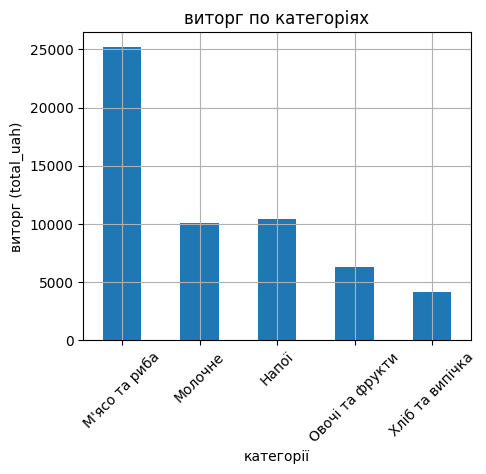

In [42]:
fig = plt.figure(figsize=(5, 4))
# df.category.value_counts().plot(kind='bar')
df.groupby('category')['total_uah'].sum().plot(kind='bar')
plt.title("виторг по категоріях")
plt.xlabel("категорії")
plt.ylabel("виторг (total_uah)")
plt.xticks(rotation=45)
plt.grid()
plt.show()

**2. Горизонтальна стовпчаста діаграма - топ-10 товарів за виторгом**

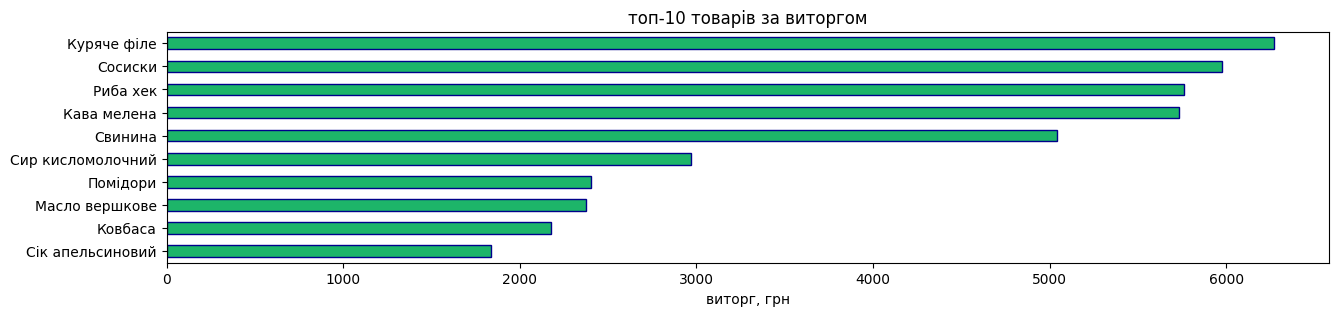

In [53]:
fig = plt.figure(figsize=(15,3))
top10_revenue = (
    df.groupby('product')['total_uah']
    .sum()
    .sort_values(ascending=True)
    .tail(10))
top10_revenue.plot(
    kind='barh',
    color='#1db569',
    edgecolor='darkblue'
)

plt.title("топ-10 товарів за виторгом")
plt.xlabel("виторг, грн")
plt.ylabel("")
plt.show()

**3. Кругова діаграма - розподіл способів оплати**

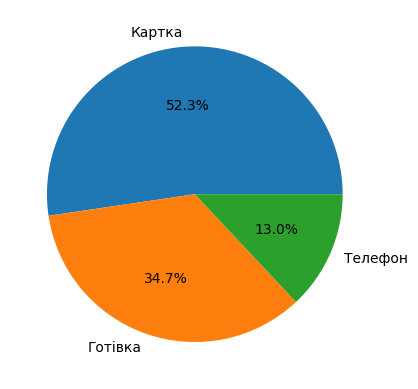

In [58]:
# fig = plt.figure()
payment_count = df.payment.value_counts()
plt.pie(payment_count, labels=payment_count.index, autopct='%1.1f%%')
# df.payment.value_counts()
plt.show()

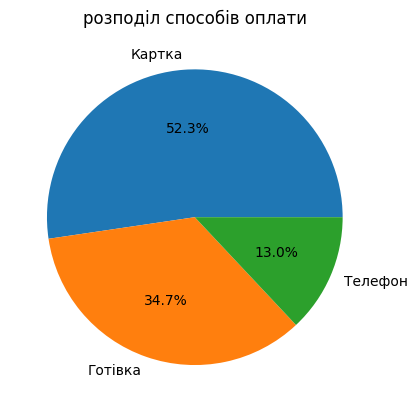

In [61]:
fig, ax =plt.subplots()
payment_count = df.payment.value_counts()
ax.pie(payment_count, labels=payment_count.index, autopct='%1.1f%%')
ax.set_title('розподіл способів оплати')
plt.show()